### Model Explainability

#### Objective

The objective of this notebook is to understand why the machine learning model predicts customer churn.

The explainability analysis includes:

- Feature Importance
- Permutation Importance
- Local Prediction Explanation
- Business Interpretation

This notebook improves model transparency and helps business stakeholders understand the factors influencing churn.

### Section 1 — Import Libraries

In [9]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix

### Section 2 — Load Dataset

In [10]:
df = pd.read_csv("../data/processed/churn_selected.csv")

df.head()

,Complains,Subscription Length,Frequency of use,Seconds of Use,Distinct Called Numbers,Customer_Engagement,Average_Call_Duration,Status,Revenue_Per_Month,Customer Value,Churn
0,0,38,71,4370,17,93,60.694444,1,5.067692,197.640,0
1,0,39,5,318,4,16,53.000000,2,1.150875,46.035,0
2,0,37,60,2453,24,443,40.213115,1,40.434737,1536.520,0
3,0,38,66,4198,35,102,62.656716,1,6.154359,240.020,0
4,0,38,58,2393,33,93,40.559322,1,3.738590,145.805,0


### Section 3 — Split Features

In [11]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape)
print(y.shape)

(2850, 10)
(2850,)


### Section 4 — Load Best Model

In [12]:
model = joblib.load("../models/customer_churn_model.pkl")

model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Section 5 — Feature Importance

In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Complains,0.439651
7,Status,0.306708
3,Seconds of Use,0.060700
5,Customer_Engagement,0.040381
6,Average_Call_Duration,0.037185
1,Subscription Length,0.031462
2,Frequency of use,0.027305
4,Distinct Called Numbers,0.024884
8,Revenue_Per_Month,0.016786
9,Customer Value,0.014938


### Section 6 — Plot Feature Importance

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.tight_layout()

plt.show()

<class 'pandas.DataFrame'>
(570, 16)
Call Failure                 int64
Complains                    int64
Subscription Length          int64
Charge Amount                int64
Seconds of Use               int64
Frequency of use             int64
Frequency of SMS             int64
Distinct Called Numbers      int64
Age Group                    int64
Tariff Plan                  int64
Status                       int64
Age                          int64
Customer Value             float64
Customer_Engagement          int64
Average_Call_Duration      float64
Revenue_Per_Month          float64
dtype: object


### Observation

The XGBoost model ranks features according to their contribution to predicting customer churn.

Features with higher importance have greater influence on model decisions.

### Section 7 — Permutation Importance

In [14]:
perm = permutation_importance(
    model,
    X,
    y,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

### Section 8 — Create Importance DataFrame

In [15]:
perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

perm_df

,Feature,Importance
7,Status,0.059965
0,Complains,0.058035
6,Average_Call_Duration,0.046281
3,Seconds of Use,0.042737
1,Subscription Length,0.035544
4,Distinct Called Numbers,0.029053
2,Frequency of use,0.022316
5,Customer_Engagement,0.020561
8,Revenue_Per_Month,0.016211
9,Customer Value,0.009298


### Section 9 — Plot Permutation Importance

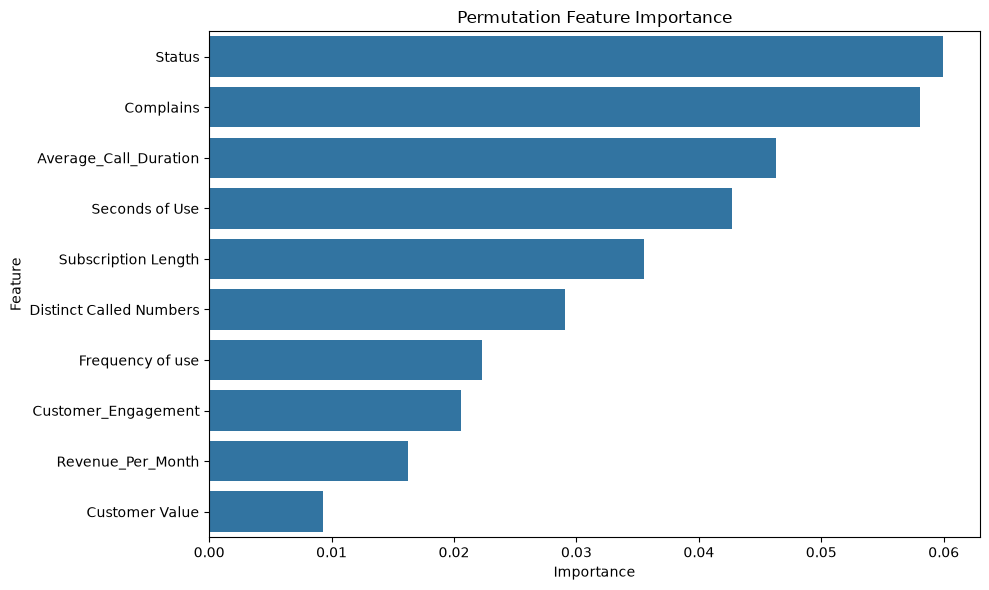

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=perm_df,
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")

plt.tight_layout()

plt.show()

### Interpretation

Permutation Importance measures how much the model performance decreases when each feature is randomly shuffled.

A larger decrease indicates that the feature is more important.

### Section 10 — Compare Both Methods

In [17]:
comparison = importance.merge(
    perm_df,
    on="Feature",
    suffixes=("_XGBoost", "_Permutation")
)

comparison

,Feature,Importance_XGBoost,Importance_Permutation
0,Complains,0.439651,0.058035
1,Status,0.306708,0.059965
2,Seconds of Use,0.060700,0.042737
3,Customer_Engagement,0.040381,0.020561
4,Average_Call_Duration,0.037185,0.046281
5,Subscription Length,0.031462,0.035544
6,Frequency of use,0.027305,0.022316
7,Distinct Called Numbers,0.024884,0.029053
8,Revenue_Per_Month,0.016786,0.016211
9,Customer Value,0.014938,0.009298


### Section 11 — Top 10 Features

In [18]:
top10 = comparison.sort_values(
    by="Importance_XGBoost",
    ascending=False
).head(10)

top10

,Feature,Importance_XGBoost,Importance_Permutation
0,Complains,0.439651,0.058035
1,Status,0.306708,0.059965
2,Seconds of Use,0.060700,0.042737
3,Customer_Engagement,0.040381,0.020561
4,Average_Call_Duration,0.037185,0.046281
5,Subscription Length,0.031462,0.035544
6,Frequency of use,0.027305,0.022316
7,Distinct Called Numbers,0.024884,0.029053
8,Revenue_Per_Month,0.016786,0.016211
9,Customer Value,0.014938,0.009298


### Section 12 — Save Explainability Report

In [19]:
comparison.to_csv(
    "../results/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


### Section 13 — Business Interpretation

#### Business Interpretation

The explainability analysis highlights the variables that most strongly influence customer churn.

Key observations:

- Complaints significantly increase churn probability.
- Customer status plays an important role in predicting churn.
- Usage-related variables such as seconds of use and frequency of use strongly influence retention.
- Customer value contributes positively to predicting long-term loyalty.
- Tariff plans contribute relatively less to churn prediction.

These insights can help telecom companies design targeted retention strategies by focusing on complaint resolution, customer engagement, and service usage.

### Section 14 — Summary

### Summary

In this notebook we:

- Loaded the best XGBoost model.
- Analyzed feature importance using XGBoost.
- Evaluated feature importance using permutation importance.
- Compared both explainability methods.
- Exported the feature importance report.
- Derived business insights from model explanations.

The explainability analysis improves transparency and supports business decision-making by identifying the key drivers of customer churn.